In [ ]:
import shutil # for copying files
import random # for shuffling the data (random.shuffle)
from pathlib import Path # file paths as objects, instead of strings

SRC = Path("../data/covers") # source path
DEST = Path("../data/split") # destination path
SPLITS = {"train": 0.7, "val": 0.15, "test":0.15}
SEED = 42

random.seed(SEED)

for class_dir in sorted(p for p in SRC.iterdir() if p.is_dir()):
    images = sorted(class_dir.glob("*.jpg"))
    random.shuffle(images)

    n = len(images)
    n_val = round(n * SPLITS["val"])
    n_test = round(n * SPLITS["test"])
    n_train = n - n_val - n_test

    boundaries = {
        "val": images[:n_val],
        "test": images[n_val : n_val + n_test],
        "train": images[n_val + n_test:]
    }

    for splits, files in boundaries.items():
        out_dir = DEST / splits / class_dir.name
        out_dir.mkdir(parents=True, exist_ok=True)
        for f in files:
            shutil.copy2(f, out_dir / f.name)
    
    print(f"{class_dir.name:<18} {n_train:>6} {n_val:>6} {n_test:>6} {n:>8}")

alternative_rock      177     38     38      253
classical             146     31     31      208
country               156     33     33      222
hiphop                165     35     35      235
house                 192     41     41      274
indie_rock            185     39     39      263
jazz                  189     41     41      271
metal                 193     41     41      275
reggae                175     37     37      249
techno                209     45     45      299


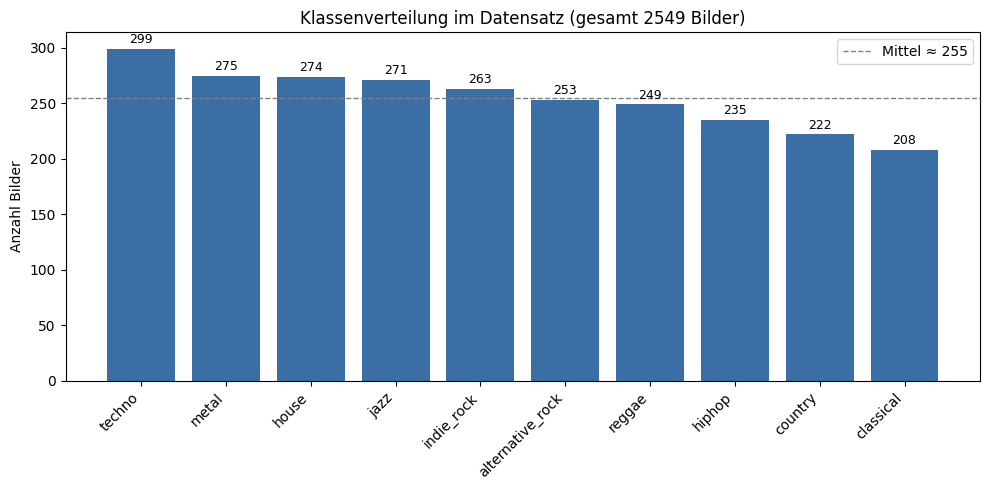

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt

DATA_DIR = Path("../data/split")
SPLITS   = ["train", "val", "test"]
EXTS     = {".jpg", ".jpeg", ".png"}

classes = sorted(p.name for p in (DATA_DIR / "train").iterdir() if p.is_dir())
counts = {
    c: sum(1 for s in SPLITS for f in (DATA_DIR / s / c).iterdir()
           if f.suffix.lower() in EXTS)
    for c in classes
}
items = sorted(counts.items(), key=lambda kv: kv[1], reverse=True)
names = [k for k, _ in items]; vals = [v for _, v in items]
mean  = sum(vals) / len(vals)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(names, vals, color="#3B6EA5")
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=45, ha="right")
ax.set_ylabel("Anzahl Bilder")
ax.set_title(f"Klassenverteilung im Datensatz (gesamt {sum(vals)} Bilder)")
ax.bar_label(bars, padding=2, fontsize=9)
ax.axhline(mean, color="gray", linestyle="--", linewidth=1, label=f"Mittel ≈ {mean:.0f}")
ax.legend(); plt.tight_layout()
plt.savefig("class-distribution.png", dpi=150, bbox_inches="tight")
plt.show()

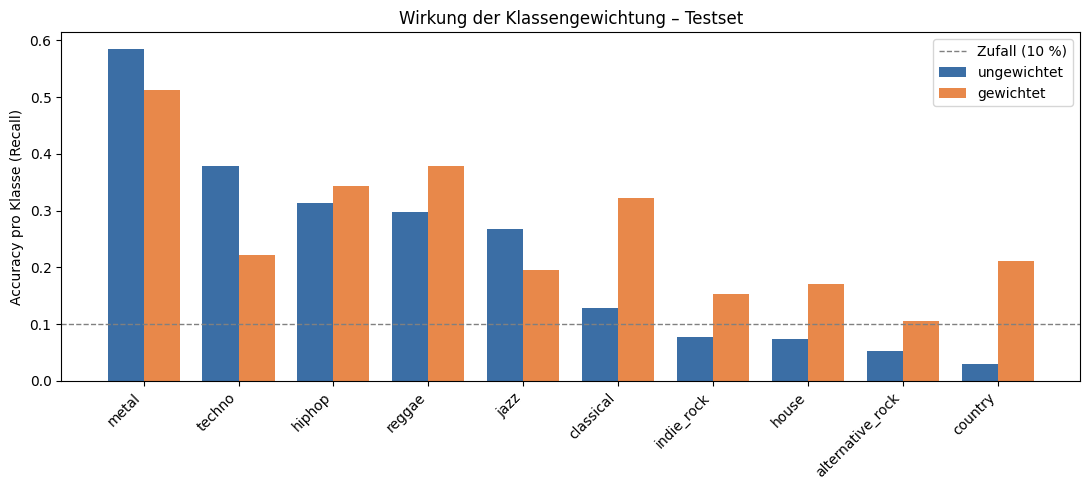

In [3]:
import numpy as np
import matplotlib.pyplot as plt

classes  = ["alternative_rock","classical","country","hiphop","house",
            "indie_rock","jazz","metal","reggae","techno"]
# Recall pro Klasse auf dem TESTSET
baseline = [0.053, 0.129, 0.030, 0.314, 0.073, 0.077, 0.268, 0.585, 0.297, 0.378]
weighted = [0.105, 0.323, 0.212, 0.343, 0.171, 0.154, 0.195, 0.512, 0.378, 0.222]

order = np.argsort(baseline)[::-1]            # nach Baseline absteigend -> Umverteilung wird sichtbar
classes  = [classes[i]  for i in order]
baseline = [baseline[i] for i in order]
weighted = [weighted[i] for i in order]

x = np.arange(len(classes)); w = 0.38
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w/2, baseline, w, label="ungewichtet", color="#3B6EA5")
ax.bar(x + w/2, weighted, w, label="gewichtet",   color="#E8884A")
ax.axhline(0.10, color="gray", linestyle="--", linewidth=1, label="Zufall (10 %)")
ax.set_xticks(x); ax.set_xticklabels(classes, rotation=45, ha="right")
ax.set_ylabel("Accuracy pro Klasse (Recall)")
ax.set_title("Wirkung der Klassengewichtung – Testset")
ax.legend(); plt.tight_layout()
plt.savefig("weighting-comparison.png", dpi=150, bbox_inches="tight")
plt.show()